In [11]:
import pandas as pd
df = pd.read_csv("/content/Marketing_Data.csv")

In [13]:
df.head()

,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


In [24]:
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    171 non-null    float64
 1   facebook   171 non-null    float64
 2   newspaper  171 non-null    float64
 3   sales      171 non-null    float64
dtypes: float64(4)
memory usage: 5.5 KB


In [16]:
df.describe()

,youtube,facebook,newspaper,sales
count,171.000000,171.000000,171.000000,171.000000
mean,178.021053,27.671579,35.240000,16.922807
std,102.449597,17.913532,24.902918,6.314608
min,0.840000,0.000000,0.360000,1.920000
25%,91.080000,11.700000,13.740000,12.540000
50%,179.760000,26.760000,31.080000,15.480000
75%,262.980000,43.680000,50.880000,20.820000
max,355.680000,59.520000,121.080000,32.400000


In [17]:
from matplotlib.pyplot import xlabel
#Visualisai Data
fig = px.line(df, y = df.columns)
fig.show()

<Axes: >

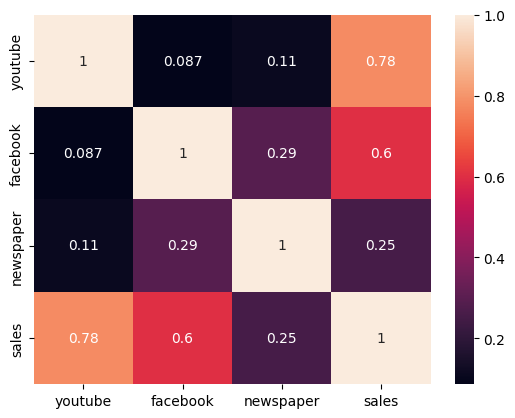

In [18]:
sns.heatmap(df.corr(), annot=True)

In [19]:
fig1 = px.scatter(df, x="youtube", y = "sales")
fig2 = px.scatter(df, x="facebook", y="sales")
fig3 = px.scatter(df, x= "newspaper", y= "sales")

fig1.show()
fig2.show()
fig3.show()

In [20]:
X = df.drop("sales", axis=1)
y= df["sales"]
X = sm.add_constant(X)

result = sm.OLS(y, X).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     503.7
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           2.09e-83
Time:                        06:33:02   Log-Likelihood:                -359.99
No. Observations:                 171   AIC:                             728.0
Df Residuals:                     167   BIC:                             740.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5059      0.400      8.772      0.0

In [21]:
# Karena variabel newspaper
X = df.drop(["newspaper", "sales"], axis=1)
y= df["sales"]
X = sm.add_constant(X)

result = sm.OLS(y, X).fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     757.8
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           8.33e-85
Time:                        06:33:03   Log-Likelihood:                -360.21
No. Observations:                 171   AIC:                             726.4
Df Residuals:                     168   BIC:                             735.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5937      0.376      9.555      0.0

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle = False, test_size = 0.4)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_train, y_train), model.score(X_test, y_test))

0.8978662550776334 0.8974433729019715


In [37]:
model.coef_

array([0.        , 0.04616537, 0.17845269])

In [39]:
model.intercept_

np.float64(3.9543409328867796)

In [41]:
df["prediction"] = model.predict(X)
df.head()

,youtube,facebook,newspaper,sales,prediction
0,84.72,19.20,48.96,12.60,11.291763
1,351.48,33.96,51.84,25.68,26.240798
2,135.48,20.88,46.32,14.28,13.934917
3,116.64,1.80,36.00,11.52,9.660284
4,318.72,24.00,0.36,20.88,22.951032


In [42]:
px.line(df, y = ["sales", "prediction"])

In [45]:
budget = 178.021053 + 27.671579 + 35.240000
budget

240.932632

In [47]:
budget_upd = 240.9

In [51]:
!pip install lightweight_mmm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 36.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of arviz to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.2/105.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.4/225.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 12.0 MB/s eta 0:00:00
  Created wheel for matplotlib: filename=matplotlib-3.6.1-cp312-cp312-linux_x86_64.whl size=11116330 sha256=e2d054009e35e315c07a4179264a49cf78321fd44c6508caeacfc5d8aac90b25
  Stored in directory: /root/.cache/pip/wheels/ef/3b/d9/b5c3e444175a84bfc4d0448a93

In [2]:
import jax.numpy as jnp
import numpyro

from lightweight_mmm import lightweight_mmm
from lightweight_mmm import optimize_media
from lightweight_mmm import plot
from lightweight_mmm import preprocessing
from lightweight_mmm import utils